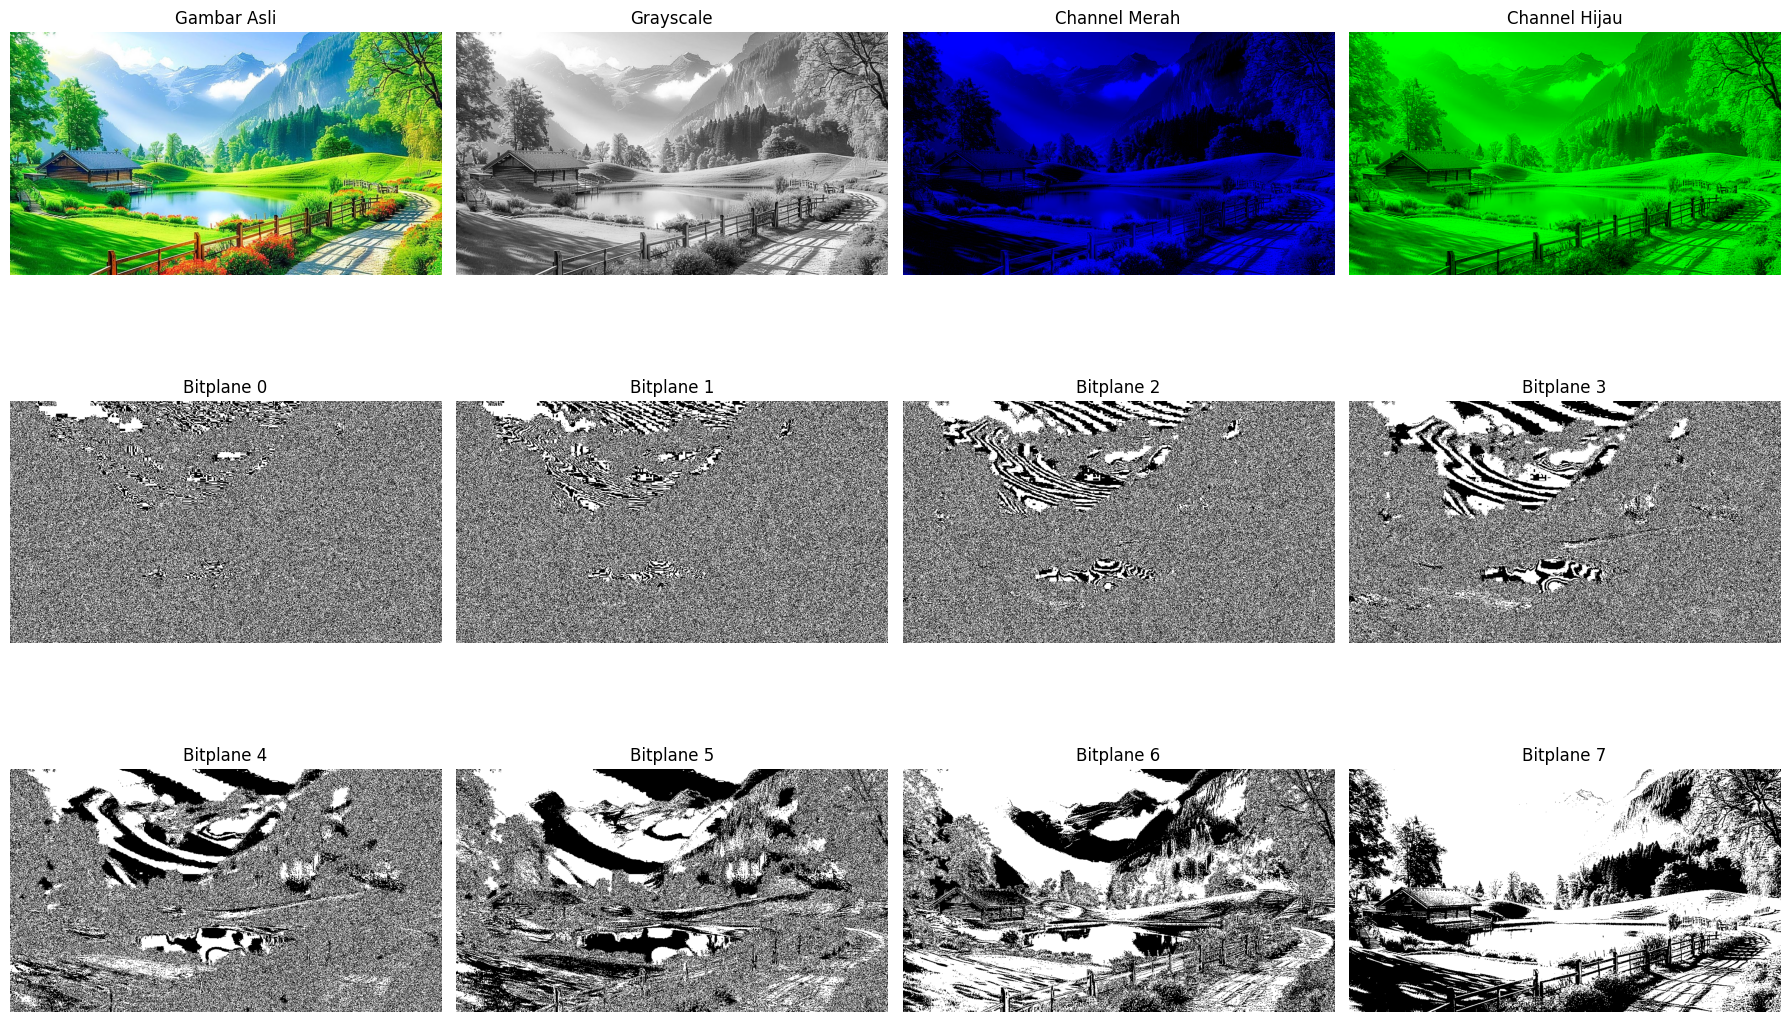

Semua hasil berhasil disimpan!


In [ ]:
# =========================================================
# TUGAS MANIPULASI CITRA DIGITAL
# Menggunakan OpenCV dan NumPy
#
# TASK Checklist:
# 1. Konversi gambar RGB ke Grayscale murni
#    dengan manipulasi bitplanes
# 2. Split gambar menjadi channel:
#    Merah, Hijau, Biru
# =========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD GAMBAR
# =========================================================

# Ganti dengan lokasi file gambar Anda
image_path = "gambar.jpg"

# Membaca gambar
img_bgr = cv2.imread(image_path)

# Validasi
if img_bgr is None:
    print("Gambar tidak ditemukan!")
    exit()

# OpenCV membaca dalam format BGR
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# =========================================================
# 1. KONVERSI RGB -> GRAYSCALE MURNI
#    DENGAN MANIPULASI BITPLANES
# =========================================================

# Ambil channel RGB
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# Rumus grayscale manual:
# Gray = 0.299R + 0.587G + 0.114B
gray = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

# =========================================================
# BITPLANE SLICING
# =========================================================

bitplanes = []

for i in range(8):
    # Ambil bit ke-i
    bitplane = ((gray >> i) & 1) * 255
    bitplanes.append(bitplane.astype(np.uint8))

# =========================================================
# 2. SPLIT CHANNEL RGB
# =========================================================

# Membuat channel kosong
zeros = np.zeros_like(R)

# Channel Merah
red_channel = cv2.merge([zeros, zeros, R])

# Channel Hijau
green_channel = cv2.merge([zeros, G, zeros])

# Channel Biru
blue_channel = cv2.merge([B, zeros, zeros])

# =========================================================
# MENAMPILKAN HASIL
# =========================================================

plt.figure(figsize=(18, 12))

# Gambar Asli
plt.subplot(3, 4, 1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

# Grayscale
plt.subplot(3, 4, 2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Channel RGB
plt.subplot(3, 4, 3)
plt.imshow(red_channel)
plt.title("Channel Merah")
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(green_channel)
plt.title("Channel Hijau")
plt.axis("off")

plt.subplot(3, 4, 5)
plt.imshow(blue_channel)
plt.title("Channel Biru")
plt.axis("off")

# Bitplanes
for i in range(8):
    plt.subplot(3, 4, i + 5)
    plt.imshow(bitplanes[i], cmap='gray')
    plt.title(f"Bitplane {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# MENYIMPAN HASIL
# =========================================================

cv2.imwrite("hasil_grayscale.png", gray)

cv2.imwrite("channel_merah.png",
            cv2.cvtColor(red_channel, cv2.COLOR_RGB2BGR))

cv2.imwrite("channel_hijau.png",
            cv2.cvtColor(green_channel, cv2.COLOR_RGB2BGR))

cv2.imwrite("channel_biru.png",
            cv2.cvtColor(blue_channel, cv2.COLOR_RGB2BGR))

print("Semua hasil berhasil disimpan!")

In [ ]:
# =========================================================
# LANJUTAN TUGAS
# =========================================================
#
# TASK Checklist:
# 3. Kompresi JPEG dengan Quality Factor:
#    Q = 10, 50, 90
#
# 4. Membuat Markdown Report:
#    - ukuran file asli
#    - ukuran file hasil kompresi
#    - persentase efisiensi storage
#
# =========================================================

import cv2
import os

# =========================================================
# FILE GAMBAR ASLI
# =========================================================

input_image = "gambar.jpg"

# Membaca gambar
img = cv2.imread(input_image)

if img is None:
    print("Gambar tidak ditemukan!")
    exit()

# =========================================================
# MENYIMPAN JPEG DENGAN BERBAGAI QUALITY FACTOR
# =========================================================

quality_list = [10, 50, 90]

compressed_files = []

for q in quality_list:

    output_name = f"compressed_Q{q}.jpg"

    # Simpan dengan kualitas tertentu
    cv2.imwrite(
        output_name,
        img,
        [cv2.IMWRITE_JPEG_QUALITY, q]
    )

    compressed_files.append(output_name)

    print(f"Berhasil menyimpan: {output_name}")

# =========================================================
# MENGHITUNG UKURAN FILE
# =========================================================

# Ukuran file asli
original_size = os.path.getsize(input_image)

results = []

for file in compressed_files:

    compressed_size = os.path.getsize(file)

    # =====================================================
    # RUMUS EFISIENSI STORAGE
    # =====================================================
    #
    # Efisiensi (%) =
    # ((Ukuran Asli - Ukuran Kompresi)
    # / Ukuran Asli) x 100
    #
    # =====================================================

    efficiency = (
        (original_size - compressed_size)
        / original_size
    ) * 100

    results.append({
        "file": file,
        "size": compressed_size,
        "efficiency": efficiency
    })

# =========================================================
# MEMBUAT MARKDOWN REPORT
# =========================================================

report = "# LAPORAN KOMPRESI JPEG\n\n"

report += "## Informasi File Asli\n\n"
report += f"- Nama File : {input_image}\n"
report += f"- Ukuran File Asli : {original_size} bytes\n\n"

report += "## Hasil Kompresi JPEG\n\n"

report += "| Quality Factor | Nama File | Ukuran (bytes) | Efisiensi Storage |\n"
report += "|---|---|---|---|\n"

for i, result in enumerate(results):

    q = quality_list[i]

    report += (
        f"| {q} "
        f"| {result['file']} "
        f"| {result['size']} "
        f"| {result['efficiency']:.2f}% |\n"
    )

# =========================================================
# ANALISIS SINGKAT
# =========================================================

report += "\n## Analisis\n\n"

report += (
    "- Quality Factor kecil menghasilkan ukuran file lebih kecil,\n"
    "  tetapi kualitas gambar menurun.\n\n"
)

report += (
    "- Quality Factor besar menghasilkan kualitas gambar lebih baik,\n"
    "  tetapi ukuran file lebih besar.\n\n"
)

report += (
    "- Kompresi JPEG efektif untuk menghemat storage\n"
    "  dengan trade-off pada kualitas visual.\n"
)

# =========================================================
# SIMPAN REPORT
# =========================================================

report_name = "laporan_kompresi.md"

with open(report_name, "w", encoding="utf-8") as f:
    f.write(report)

print("\nMarkdown report berhasil dibuat!")
print(f"Nama file report: {report_name}")

# =========================================================
# MENAMPILKAN HASIL DI TERMINAL
# =========================================================

print("\n===== HASIL KOMPRESI =====")

for i, result in enumerate(results):

    print(f"\nQuality Factor : {quality_list[i]}")
    print(f"File            : {result['file']}")
    print(f"Ukuran          : {result['size']} bytes")
    print(f"Efisiensi       : {result['efficiency']:.2f}%")

Berhasil menyimpan: compressed_Q10.jpg
Berhasil menyimpan: compressed_Q50.jpg
Berhasil menyimpan: compressed_Q90.jpg

Markdown report berhasil dibuat!
Nama file report: laporan_kompresi.md

===== HASIL KOMPRESI =====

Quality Factor : 10
File            : compressed_Q10.jpg
Ukuran          : 54515 bytes
Efisiensi       : 77.95%

Quality Factor : 50
File            : compressed_Q50.jpg
Ukuran          : 148473 bytes
Efisiensi       : 39.93%

Quality Factor : 90
File            : compressed_Q90.jpg
Ukuran          : 356042 bytes
Efisiensi       : -44.04%
